In [ ]:
import xarray as xr
import seawater as sw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import yaml
import os
from xhistogram.xarray import histogram as xhist
import seawater as gsw
from shapely.geometry import Polygon
import tqdm
import glob
from scipy.stats import linregress
import dask
import dask.distributed
import dask_jobqueue
from matplotlib.offsetbox import AnchoredText
import warnings

warnings.filterwarnings("ignore")

In [2]:
cluster = dask_jobqueue.SLURMCluster(
    # Dask worker size
    cores=4,
    memory="16GB",
    processes=1,  # Dask workers per job
    # SLURM job script things
    queue="base",
    walltime="08:00:00",
    # Dask worker network and temporary storage
    interface="ib0",
    local_directory="$TMPDIR",  # for spilling tmp data to disk
    log_directory="slurm/",
)

client = dask.distributed.Client(cluster)

cluster.scale(jobs=15)  # 15
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://172.18.4.22:45597/status,
Dashboard: http://172.18.4.22:45597/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.18.4.22:36505,Workers: 0
Dashboard: http://172.18.4.22:45597/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
def filter_beached_particles(ds, dim=None):
    # Identify particles that reach zero salinity
    particles_reach_zero_salinity = (ds.salt == 0).any(dim)

    # Identify particles that have not reached zero salinity (beached)
    particles_beached = ~particles_reach_zero_salinity

    # Filter the dataset to include only particles that have not reached zero salinity
    ds_particles_reach_zero_salinity_beached = ds.where(
        particles_beached.load(), drop=True
    )

    return ds_particles_reach_zero_salinity_beached


def compute_density(ds):
    ds_density = (
        xr.apply_ufunc(
            gsw.eos80.pden,
            ds.salt,
            ds.temp,
            0,
            dask="parallelized",
            output_dtypes=[np.float64],
        )
        - 1000
    )
    ds_add_dens = ds.assign(sigma0=ds_density)
    return ds_add_dens


def calc_min_max(ds):
    lon_min = float(ds.lon.min().values)
    lon_max = float(ds.lon.max().values)
    lat_min = float(ds.lat.min().values)
    lat_max = float(ds.lat.max().values)
    res = {
        "lon_min": lon_min,
        "lon_max": lon_max,
        "lat_min": lat_min,
        "lat_max": lat_max,
    }
    return res


def filter_particles_by_density(ds, density_threshold, dim=None):
    # Identify particles with density less than the threshold
    particles_less_than_threshold = (ds.sigma0 < density_threshold).any(dim)

    # Identify particles that reach or exceed the threshold
    particles_that_reach_threshold = ~particles_less_than_threshold

    # Filter the dataset to include only particles that exceed the threshold
    ds_particles_greater_than_threshold = ds.where(
        particles_that_reach_threshold.compute(), drop=True
    )

    return ds_particles_greater_than_threshold


hours_to_days = 0.0416667
hours_to_months = 0.00136986
hours_to_years = 0.000114155
time_conversion = hours_to_days
velocity_conversion = (
    1852 * 60
)  # multiply the value of the V field with 1852 * 60 (the number of meters in 1 degree of latitude)


def rechunk_for_hist(var):
    return var.chunk({"trajectory": 50, "obs": -1})


# rechunk lat and lon
def rechunk_lat_lon(ds):
    lon_rechunk = rechunk_for_hist(ds["lon"])
    lat_rechunk = rechunk_for_hist(ds["lat"])

    return lon_rechunk, lat_rechunk


def get_mean_maps(ds, lon_rechunk, lat_rechunk):
    weights = xr.ones_like(ds)
    weighted_sum = xhist(
        lon_rechunk,
        lat_rechunk,
        bins=[lon_bins, lat_bins],
        weights=ds,
        dim=["obs", "trajectory"],
    )
    counts = xhist(
        lon_rechunk,
        lat_rechunk,
        bins=[lon_bins, lat_bins],
        weights=weights,
        dim=["obs", "trajectory"],
    )
    mean_temp = weighted_sum / counts
    return mean_temp

In [4]:
# converting the age from nano seconds
inpath = "/gxfs_work/geomar/smomw452/GLORYS12/Data/"
hours_to_days = 0.0416667
hours_to_months = 0.00136986
hours_to_years = 0.000114155
time_conversion = hours_to_days
velocity_conversion = (
    1852 * 60
)  # multiply the value of the V field with 1852 * 60 (the number of meters in 1 degree of latitude)

mesh_mask = xr.open_dataset(inpath + "mesh_masks/mesh_mask.nc")
mesh_hzgr = xr.open_dataset(inpath + "mesh_masks/mesh_hzgr.nc")
mesh_hgr = xr.open_dataset(inpath + "mesh_masks/mesh_hgr.nc")

z = mesh_hzgr.e3t_0
t_mask = mesh_mask.tmask

# bathymetry (Depth level) at every grid point
bathymetry = (
    (z * t_mask)
    .isel(t=0)
    .sum(dim="z")
    .assign_coords({"nav_lat": mesh_hgr.nav_lat, "nav_lon": mesh_hgr.nav_lon})
)

# turn zeros into nans, easier to see where continents are
bath_total_nans = bathymetry.where(bathymetry != 0)
land_mask = mesh_mask.tmask.where(mesh_mask.tmask != 0).isel(t=0, z=0)

In [5]:
inpath = "/gxfs_work/geomar/smomw452/GLORYS12/schillerweiss_2025/data/level2_uniform_release_clim_land_nans/"

ds_overflows = xr.open_mfdataset(
    sorted(
        glob.glob(
            inpath + "density_filtered_uniform_parcels_release_2000-2020_chunk_*.zarr"
        )
    ),
    engine="zarr",
    chunks="auto",
    combine="nested",
    concat_dim="trajectory",
)

# Reset trajectory index to clean 0, 1, 2, ...N
ds_overflows["trajectory"] = np.arange(ds_overflows.trajectory.size)

# Just use ds_overflows directly for analysis - no need to save combined
ds_overflows = ds_overflows.chunk({"trajectory": 2_000, "obs": -1})

## set 10 year backtracking limit

ds_overflows = ds_overflows.where(ds_overflows.age * hours_to_years > -10, drop=False)

In [ ]:
outdir = "/gxfs_work/geomar/smomw452/GLORYS12/schillerweiss_2025/notebooks/"
if not os.path.exists(outdir):
    os.makedirs(outdir)
if os.path.exists(f"{outdir}/minmax.yaml"):
    with open(f"{outdir}/minmax.yaml", "r") as file:
        results = yaml.load(file, Loader=yaml.FullLoader)
else:
    results = calc_min_max(ds_overflows)
    with open(f"{outdir}/minmax.yaml", "w") as file:
        yaml.dump(results, file)

n = 0.25  # .25
lon_bins = np.arange(results["lon_min"], results["lon_max"], n)
lat_bins = np.arange(results["lat_min"], results["lat_max"], n)

In [6]:
def calculate_slope_intercept(x1, y1, x2, y2):
    m = (y2 - y1) / (x2 - x1)
    b = y1 - m * x1
    return m, b


def process_ocean_basins(bathy):
    # Lofoten
    # m, b = calculate_slope_intercept(-4.5,70.7,2,68.4)
    # m3, b3 = calculate_slope_intercept(9,68.4,14,69.6)
    # m4, b4 = calculate_slope_intercept(6,72.5,-4.5,70.7)
    # m5,b5 = calculate_slope_intercept(14,69.6,6,72.5)

    m, b = calculate_slope_intercept(-4.5, 70.7, 2, 68.6)
    m3, b3 = calculate_slope_intercept(9, 68.6, 14, 69.6)
    m4, b4 = calculate_slope_intercept(6, 72.5, -4.5, 70.7)
    m5, b5 = calculate_slope_intercept(14, 69.6, 6, 72.5)

    ds_window = bathy.lat >= bathy.lon * m + b
    ds_window2 = bathy.lat >= 68.6
    ds_window3 = bathy.lat >= bathy.lon * m3 + b3
    ds_window4 = bathy.lat <= bathy.lon * m4 + b4
    ds_window5 = bathy.lat <= bathy.lon * m5 + b5

    lofoten = (ds_window & ds_window2 & ds_window3 & ds_window4 & ds_window5).astype(
        int
    )
    lofoten = xr.where(lofoten > 0, 1, 0).astype(int)
    lofoten = bathy.where(lofoten, drop=False)

    # Greenland sea
    m, b = calculate_slope_intercept(-12, 74.5, -2.5, 76.7)
    m2, b2 = calculate_slope_intercept(-2.5, 76.7, 4, 74)
    m3, b3 = calculate_slope_intercept(4, 74, -1, 73)

    ds_window = bathy.lat <= bathy.lon * m + b
    ds_window2 = bathy.lat <= bathy.lon * m2 + b2
    ds_window3 = bathy.lat >= bathy.lon * m3 + b3
    ds_window4 = bathy.lat >= 73
    ds_window5 = bathy.lon >= -12
    gsea = (ds_window & ds_window2 & ds_window3 & ds_window4 & ds_window5).astype(int)
    gsea = xr.where(gsea > 0, 1, 0).astype(int)
    gsea = bathy.where(gsea, drop=False)

    # Iceland sea
    m2, b2 = calculate_slope_intercept(-12.5, 66.5, -14, 67.5)
    ds_window = bathy.lat >= 66.5
    ds_window2 = bathy.lat >= bathy.lon * m2 + b2
    ds_window3 = bathy.lon <= -8.75
    ds_window4 = bathy.lat <= 70.2
    ds_window5 = bathy.lon >= -14
    isea = (ds_window & ds_window2 & ds_window5 & ds_window3 & ds_window4).astype(
        int
    )  # & ds_window2 & ds_window3 & ds_window4
    isea = xr.where(isea > 0, 1, 0).astype(int)
    isea = bathy.where(isea, drop=False)
    isea_box = (
        (bathy.lon > -13.5) & (bathy.lat > 67.5) & (bathy.lon < -9.2) & (bathy.lat < 70)
    )  # lon > -14
    isea = bathy.where(isea_box, drop=False)

    # norwegian basin
    m2, b2 = calculate_slope_intercept(-3, 69.5, 1, 67.5)

    ds_window = bathy.lon >= -6.2
    ds_window2 = bathy.lat >= 64
    ds_window3 = bathy.lon <= 1
    ds_window4 = bathy.lat <= 69.5
    ds_window5 = bathy.lat <= bathy.lon * m2 + b2

    nbasin = (ds_window & ds_window2 & ds_window3 & ds_window4 & ds_window5).astype(int)
    nbasin = xr.where(nbasin > 0, 1, 0).astype(int)
    nbasin = bathy.where(nbasin, drop=False)

    return {"lofoten": lofoten, "greenland": gsea, "iceland": isea, "norwegian": nbasin}


def filter_trajectories(ds_line, ds_all_trajs):
    """
    filters trajectories based on whether they cross the line.

    parameters:
    ds_orig (xarray.Dataset): original dataset containing trajectory data.
    ds_line (xarray.Dataset): dataset containing the line information.

    returns:
    traj_not_line (xarray.Dataset): trajectories that do not cross the line.
    traj_line (xarray.Dataset): trajectories that cross the line.
    traj_all (xarray.Dataset): all trajectories from the original dataset.
    """

    nans_per_traj = (ds_line["temp"].isnull()).sum(dim="obs").compute()

    traj_not_line = ds_all_trajs.sel(
        trajectory=(nans_per_traj == ds_line.obs.size)
    )  # select all trajs with all nans, i.e. not crossing
    traj_line = ds_all_trajs.sel(
        trajectory=(nans_per_traj != ds_line.obs.size)
    )  # select all trajs with at least one non-nan, i.e. crossing

    traj_all = ds_all_trajs

    return {
        "traj_line": traj_line,
        "traj_not_line": traj_not_line,
        "traj_all": traj_all,
    }


def create_polygon(vertices):
    polygon = Polygon(vertices)
    x_coords, y_coords = polygon.exterior.xy
    return polygon, x_coords, y_coords


vertices_Gsea = [(-12, 74.5), (-2.5, 76.7), (4, 74), (-1, 73), (-12, 73), (-12, 74.5)]

vertices_Lofoten = [
    (-4.5, 70.7),
    (2, 68.6),
    (9, 68.6),
    (14, 69.6),
    (6, 72.5),
    (-4.5, 70.7),
]

vertices_Iceland = [(-13.5, 70), (-9.2, 70), (-9.2, 67.5), (-13.5, 67.5)]

vertices_Norwegian = [
    (-6.2, 64),
    (-6.2, 69.5),
    (-3, 69.5),
    (1, 67.5),
    (1, 64),
    (-6.2, 64),
]


# Create polygons and extract coordinates
polygon_Gsea, x_GSea, y_GSea = create_polygon(vertices_Gsea)
polygon_Lofoten, x_Lofoten, y_Lofoten = create_polygon(vertices_Lofoten)
polygon_Iceland, x_Iceland, y_Iceland = create_polygon(vertices_Iceland)
polygon_Norwegian, x_Norwegian, y_Norwegian = create_polygon(vertices_Norwegian)


def compute_probability_perc(traj_line_not_all):
    # Create a 2D histogram of the latitude and longitude
    heat_map_time_non = xhist(
        traj_line_not_all.lat,
        traj_line_not_all.lon,
        bins=[lat_bins, lon_bins],
        dim=["obs"],
        bin_dim_suffix="",
    )

    # Count unique trajectories in each bin
    heat_map_time_unique_non = (heat_map_time_non > 0).sum(dim="trajectory")

    # Calculate the percentage of trajectories in each bin
    heat_map_percentage_non = (
        heat_map_time_unique_non / ds_overflows.trajectory.size
    ) * 100

    # Compute the result
    heat_map_percentage_non_cp = heat_map_percentage_non.compute()

    return heat_map_percentage_non_cp


def calculate_heatmap(ds):
    heat_map = xhist(
        ds.lat, ds.lon, bins=[lat_bins, lon_bins], dim=["trajectory"], bin_dim_suffix=""
    )
    heat_map = heat_map.where(heat_map > 0)
    return heat_map


def compute_probability_weighted(traj_line_not_all):
    """
    Compute a heatmap where each bin counts how many particle positions occurred there,
    rather than only counting unique trajectories. This highlights regions where particles
    pass even if spread over a wide area.
    """
    # 2D histogram over lat/lon; sum over 'obs' (all recorded positions)
    heat_map_counts = xhist(
        traj_line_not_all.lat,
        traj_line_not_all.lon,
        bins=[lat_bins, lon_bins],
        dim=["obs"],
        bin_dim_suffix="",
    )

    # sum over trajectories to get total positions per bin
    heat_map_total = heat_map_counts.sum(dim="trajectory").compute()

    # normalize to fraction of all positions
    heat_map_prob = heat_map_total / heat_map_total.sum()

    return heat_map_prob

In [15]:
outdir = "/gxfs_work/geomar/smomw452/GLORYS12/schillerweiss_2025/notebooks/"
if not os.path.exists(outdir):
    os.makedirs(outdir)
if os.path.exists(f"{outdir}/minmax.yaml"):
    with open(f"{outdir}/minmax.yaml", "r") as file:
        results = yaml.load(file, Loader=yaml.FullLoader)
else:
    results = calc_min_max(ds_overflows)
    with open(f"{outdir}/minmax.yaml", "w") as file:
        yaml.dump(results, file)

n = 0.25  # .25
lon_bins = np.arange(results["lon_min"], results["lon_max"], n)
lat_bins = np.arange(results["lat_min"], results["lat_max"], n)

In [ ]:
lon_rechunk, lat_rechunk = (
    rechunk_lat_lon(ds_overflows)[0],
    rechunk_lat_lon(ds_overflows)[1],
)


heatmap_all = compute_probability_perc(ds_overflows)
heatmap_weighted = compute_probability_weighted(ds_overflows)

In [8]:
heatmap_all = xr.open_dataset("netcdfs/heatmaps.nc")["heatmap_all"]
heatmap_weighted = xr.open_dataset("netcdfs/heatmaps.nc")["heatmap_weighted"]

In [9]:
msk = (
    xr.where(heatmap_all > 1, 1, np.nan)
    .rename({"lat": "lat_bin", "lon": "lon_bin"})
    .values
)

contour_interval = 700

contour_levels = np.arange(
    np.floor(bathymetry.min() / contour_interval) * contour_interval,
    np.ceil(bathymetry.max() / contour_interval) * contour_interval,
    contour_interval,
)

lon, lat = heatmap_all.lon.values, heatmap_all.lat.values

In [ ]:
mean_depth = get_mean_maps(
    ds_overflows.z, rechunk_lat_lon(ds_overflows)[0], rechunk_lat_lon(ds_overflows)[1]
).compute()

# mean_depth.to_netcdf('netcdfs/mean_depth.nc')

In [10]:
mean_depth = xr.open_dataset("netcdfs/mean_depth.nc").histogram_lon_lat

In [11]:
def month_selection(data, month1, month2):
    months = data["start_time"].dt.month.compute()  # get months from datetime coord
    month_sel = (months >= month1) & (months <= month2)
    return data.where(month_sel, drop=True)


ds_overflows_march = month_selection(
    ds_overflows, 3, 3
)  # .sel(start_time=slice("2000", None))

In [ ]:
mean_depth_march = get_mean_maps(
    ds_overflows_march.z,
    rechunk_lat_lon(ds_overflows_march)[0],
    rechunk_lat_lon(ds_overflows_march)[1],
).compute()

# mean_depth_march.to_netcdf('netcdfs/mean_depth_march.nc')

In [13]:
mean_depth_march = xr.open_dataset("netcdfs/mean_depth_march.nc").histogram_lon_lat

In [16]:
# import GLORYS12 MLD output

MLD = xr.open_mfdataset(
    "/gxfs_work/geomar/smomw452/GLORYS12/Data/MLD_monthly/somxl010_*.nc",
    combine="by_coords",
).somxl010

MLD_annual_maximum = (
    MLD.groupby("time_counter.year")
    .max(dim="time_counter")
    .assign_coords({"nav_lat": mesh_mask.nav_lat, "nav_lon": mesh_mask.nav_lon})
)

years = MLD_annual_maximum.year
regridded_MLD_max = np.zeros((len(years), len(lat_bins) - 1, len(lon_bins) - 1))

for i, year in tqdm.tqdm(enumerate(years)):
    year_data = MLD_annual_maximum.sel(year=year)

    # regrid
    regridded_MLD_max[i] = xhist(
        year_data.nav_lat,
        year_data.nav_lon,
        bins=[lat_bins, lon_bins],
        weights=year_data,
    ) / xhist(year_data.nav_lat, year_data.nav_lon, bins=[lat_bins, lon_bins])

# convert back to xarray
regridded_MLD_da = xr.DataArray(
    regridded_MLD_max,
    coords=[years, lat_bins[:-1], lon_bins[:-1]],
    dims=["year", "lat_bin", "lon_bin"],
)
MLD_ann_max_mean_regridded = (
    regridded_MLD_da.sel(year=slice("2000", None))
    .mean(dim="year")
    .reindex_like(mean_depth, method="nearest")
)

33it [00:27,  1.19it/s]


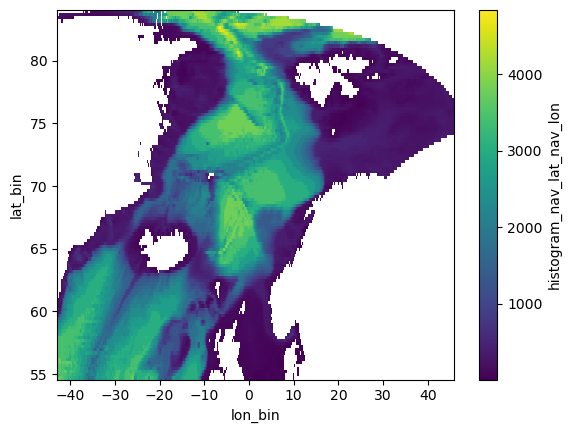

In [17]:
bathymetry_nans = bathymetry.where(bathymetry != 0)

bathymetry_nans_regridded = xhist(
    mesh_mask.nav_lat,
    mesh_mask.nav_lon,
    bins=[lat_bins, lon_bins],
    weights=bathymetry_nans,
) / xhist(mesh_mask.nav_lat, mesh_mask.nav_lon, bins=[lat_bins, lon_bins])

bathymetry_nans_regridded = xr.DataArray(
    bathymetry_nans_regridded,
    coords=[lat_bins[:-1], lon_bins[:-1]],
    dims=["lat_bin", "lon_bin"],
)

bathymetry_nans_regridded.plot()

In [18]:
geo_mask = xr.DataArray(
    np.ones((len(lat_bins) - 1, len(lon_bins) - 1)),
    coords=[lat_bins[:-1], lon_bins[:-1]],
    dims=["lat_bin", "lon_bin"],
)

# Mask out Irminger Sea and eastern subpolar North Atlantic
geo_mask = geo_mask.where(
    (geo_mask.lat_bin > 63)  # keep everything north of 63N
    | ((geo_mask.lon_bin > -7) & (geo_mask.lat_bin > 59))  # keep Norwegian/North Sea
    | ((geo_mask.lon_bin > 0) & (geo_mask.lat_bin > 57))  # keep further east
)
geo_mask2 = geo_mask.where(
    ~(
        (geo_mask.lat_bin >= 63)
        & (geo_mask.lat_bin <= 66)
        & (geo_mask.lon_bin >= -40)
        & (geo_mask.lon_bin <= -10)
    )
)

msk = xr.where(
    (
        bathymetry_nans_regridded.where(bathymetry_nans_regridded > 1000)
        * geo_mask
        * geo_mask2
    )
    > 0,
    1,
    np.nan,
)

msk = msk.values

## Figure 4

In [19]:
plt.rcParams.update({"font.size": 15})

lon, lat = heatmap_all.lon, heatmap_all.lat

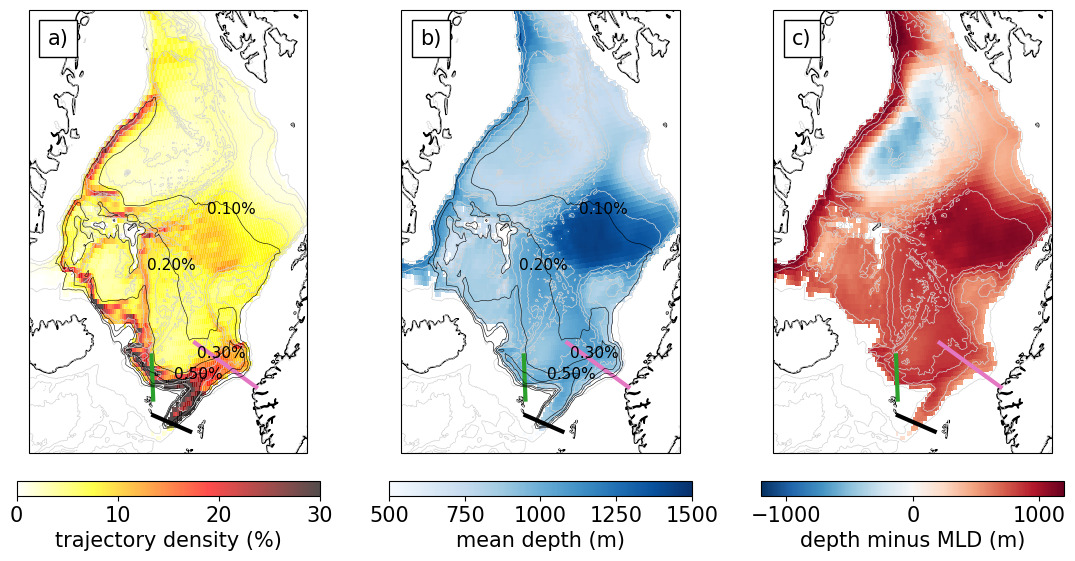

In [20]:
# Projection
proj = ccrs.LambertConformal(central_longitude=-10, central_latitude=70)

# Create 3x1 figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={"projection": proj})
ax1, ax2, ax3 = axes

#######################
# Map 1: trajectory density
#######################
ax1.set_extent([-20, 10, 59, 80], crs=ccrs.PlateCarree())
m1 = ax1.pcolormesh(
    lon,
    lat,
    heatmap_all * msk,
    cmap="hot_r",
    vmin=0,
    vmax=30,
    alpha=0.7,
    transform=ccrs.PlateCarree(),
)
ax1.coastlines()
ax1.contour(
    mesh_mask.nav_lon,
    mesh_mask.nav_lat,
    bathymetry,
    levels=contour_levels,
    colors="lightgray",
    linewidths=0.5,
    transform=ccrs.PlateCarree(),
)
ax1.plot(
    [5.5, -1],
    [62.24, 65.0],
    color="tab:pink",
    transform=ccrs.PlateCarree(),
    linewidth=3,
)
ax1.plot(
    [-6.43, -6.43],
    [62.15, 64.5],
    color="tab:green",
    transform=ccrs.PlateCarree(),
    linewidth=3,
)
ax1.plot(
    [-6.5, -2.5], [61.3, 60.3], color="k", transform=ccrs.PlateCarree(), linewidth=3
)

cs = ax1.contour(
    heatmap_weighted.lon,
    heatmap_weighted.lat,
    heatmap_weighted * 1000,
    levels=[0.1, 0.2, 0.3, 0.5],
    colors="k",
    linewidths=0.4,
    transform=ccrs.PlateCarree(),
)
for i, level in enumerate(cs.levels):
    paths = cs.collections[i].get_paths()
    if len(paths) == 0:
        continue
    vertices = paths[0].vertices
    idx = len(vertices) // 4
    ax1.text(
        vertices[idx, 0],
        vertices[idx, 1],
        f"{level:.2f}%",
        transform=ccrs.PlateCarree(),
        fontsize=11,
        color="k",
        ha="center",
        va="center",
    )

fig.colorbar(m1, ax=ax1, orientation="horizontal", pad=0.05, shrink=0.3).set_label(
    "trajectory density (%)"
)
ax1.add_artist(AnchoredText("a)", prop=dict(size=15), frameon=True, loc="upper left"))

#######################
# Map 2: mean depth
#######################
ax2.set_extent([-20, 10, 59, 80], crs=ccrs.PlateCarree())
m2 = ax2.pcolormesh(
    lon,
    lat,
    msk * mean_depth.T,
    vmin=500,
    vmax=1500,
    cmap="Blues",
    transform=ccrs.PlateCarree(),
)
ax2.coastlines()
ax2.contour(
    mesh_mask.nav_lon,
    mesh_mask.nav_lat,
    bathymetry,
    levels=contour_levels,
    colors="lightgray",
    linewidths=0.5,
    transform=ccrs.PlateCarree(),
)
ax2.plot(
    [5.5, -1],
    [62.24, 65.0],
    color="tab:pink",
    transform=ccrs.PlateCarree(),
    linewidth=3,
)
ax2.plot(
    [-6.43, -6.43],
    [62.15, 64.5],
    color="tab:green",
    transform=ccrs.PlateCarree(),
    linewidth=3,
)
ax2.plot(
    [-6.5, -2.5], [61.3, 60.3], color="k", transform=ccrs.PlateCarree(), linewidth=3
)

cs = ax2.contour(
    heatmap_weighted.lon,
    heatmap_weighted.lat,
    heatmap_weighted * 1000,
    levels=[0.1, 0.2, 0.3, 0.5],
    colors="k",
    linewidths=0.4,
    transform=ccrs.PlateCarree(),
)
for i, level in enumerate(cs.levels):
    paths = cs.collections[i].get_paths()
    if len(paths) == 0:
        continue
    vertices = paths[0].vertices
    idx = len(vertices) // 4
    ax2.text(
        vertices[idx, 0],
        vertices[idx, 1],
        f"{level:.2f}%",
        transform=ccrs.PlateCarree(),
        fontsize=11,
        color="k",
        ha="center",
        va="center",
    )

fig.colorbar(m2, ax=ax2, orientation="horizontal", pad=0.05, shrink=0.3).set_label(
    "mean depth (m)"
)
ax2.add_artist(AnchoredText("b)", prop=dict(size=15), frameon=True, loc="upper left"))

#######################
# Map 3: depth minus MLD
#######################
ax3.set_extent([-20, 10, 59, 80], crs=ccrs.PlateCarree())
m3 = ax3.pcolormesh(
    mean_depth.lon_bin,
    mean_depth.lat_bin,
    (mean_depth.T - MLD_ann_max_mean_regridded) * msk,
    cmap="RdBu_r",
    vmin=-1200,
    vmax=1200,
    transform=ccrs.PlateCarree(),
)
ax3.coastlines()
ax3.contour(
    mesh_mask.nav_lon,
    mesh_mask.nav_lat,
    bathymetry,
    levels=contour_levels,
    colors="lightgray",
    linewidths=0.5,
    transform=ccrs.PlateCarree(),
)
ax3.plot(
    [5.5, -1],
    [62.24, 65.0],
    color="tab:pink",
    transform=ccrs.PlateCarree(),
    linewidth=3,
)
ax3.plot(
    [-6.43, -6.43],
    [62.15, 64.5],
    color="tab:green",
    transform=ccrs.PlateCarree(),
    linewidth=3,
)
ax3.plot(
    [-6.5, -2.5], [61.3, 60.3], color="k", transform=ccrs.PlateCarree(), linewidth=3
)

fig.colorbar(m3, ax=ax3, orientation="horizontal", pad=0.05, shrink=0.3).set_label(
    "depth minus MLD (m)"
)
ax3.add_artist(AnchoredText("c)", prop=dict(size=15), frameon=True, loc="upper left"))

fig.subplots_adjust(wspace=-0.8)
plt.tight_layout()
# plt.savefig("Figures/Fig4_heatmap_depth", dpi=300, bbox_inches="tight")
plt.show()

## Figure 5

In [ ]:
grouped_data = ds_overflows.groupby(ds_overflows["start_time"].compute())
grouped_datasets = {start_time: group for start_time, group in grouped_data}
grouped_values = list(grouped_datasets.values())

In [ ]:
start_year = 2000
end_year = 2020
annual_data = {}

for year in range(start_year, end_year + 1):
    # Filter groups by actual start_time year instead of index arithmetic
    year_groups = [
        group
        for start_time, group in zip(grouped_datasets.keys(), grouped_datasets.values())
        if pd.Timestamp(start_time).year == year
    ]

    if len(year_groups) == 0:
        print(f"{year}: no releases found, skipping")
        continue

    concatenated_data = xr.concat(year_groups, dim="trajectory")
    annual_data[year] = concatenated_data
    # print(f"{year}: {len(year_groups)} releases, {concatenated_data.sizes}")

In [ ]:
def get_mean_maps_weighted(ds, age_data, lon_rechunk, lat_rechunk):
    # Compute dt lazily
    dt = np.abs(age_data.diff(dim="obs"))

    # Pad first obs by repeating second value — drop coords to avoid index conflict
    dt_first = dt.isel(obs=0).drop_vars("obs")
    dt_no_coord = dt.drop_vars("obs")
    dt = xr.concat([dt_first, dt_no_coord], dim="obs")

    # Reset obs coordinate to match ds
    dt = dt.assign_coords(obs=ds.obs)

    # Weighted sum
    weighted_sum = xhist(
        lon_rechunk,
        lat_rechunk,
        bins=[lon_bins, lat_bins],
        weights=ds * dt,
        dim=["obs", "trajectory"],
    )
    # Sum of weights
    weight_sum = xhist(
        lon_rechunk,
        lat_rechunk,
        bins=[lon_bins, lat_bins],
        weights=dt,
        dim=["obs", "trajectory"],
    )
    return weighted_sum / weight_sum

In [ ]:
traj = ds_overflows.isel(trajectory=0)

dt = np.abs(traj.age.diff(dim="obs"))

In [ ]:
mean_temp_maps_weighted = {}
for year in tqdm.tqdm(range(2000, 202)):
    year_data = annual_data.get(year)
    temp_data = year_data.temp
    age_data = year_data.age
    lat, lon = rechunk_lat_lon(year_data)
    mean_temp_maps_weighted[year] = get_mean_maps_weighted(
        temp_data, age_data, lat, lon
    ).compute()

In [ ]:
mean_depth_maps = {}

for year in tqdm.tqdm(range(2000, 2021)):
    depth_data = annual_data.get(year).z
    lat, lon = rechunk_lat_lon(annual_data.get(year))
    mean_depth_maps[year] = get_mean_maps(depth_data, lat, lon).compute()

In [ ]:
mean_temp_maps = {}

for year in tqdm.tqdm(range(2000, 2021)):
    temp_data = annual_data.get(year).temp
    lat, lon = rechunk_lat_lon(annual_data.get(year))
    mean_temp_maps[year] = get_mean_maps(temp_data, lat, lon).compute()

In [ ]:
mean_salt_maps = {}

for year in tqdm.tqdm(range(2000, 2021)):
    salt_data = annual_data.get(year).salt
    lat, lon = rechunk_lat_lon(annual_data.get(year))
    mean_salt_maps[year] = get_mean_maps(salt_data, lat, lon).compute()

In [ ]:
output_dir = "/gxfs_work/geomar/smomw452/GLORYS12/Scripts_for_figs/netcdfs/"
os.makedirs(output_dir, exist_ok=True)

for year, data in mean_depth_maps.items():
    data.to_netcdf(f"{output_dir}mean_depth_{year}.nc")
    print(f"Saved depth {year}")


# for year, data in mean_temp_maps.items():
#     data.to_netcdf(f'{output_dir}mean_temp_{year}.nc')
#     print(f"Saved temp {year}")

# for year, data in mean_salt_maps.items():
#     data.to_netcdf(f'{output_dir}mean_salt_{year}.nc')
#     print(f"Saved salt {year}")

In [ ]:
# Load and concatenate temp
temp_files = [f"{output_dir}mean_depth_{year}.nc" for year in range(2000, 2021)]
temp_all = xr.concat(
    [xr.open_dataset(f) for f in temp_files],
    dim=pd.Index(range(2000, 2021), name="year"),
)
temp_all.to_netcdf(f"{output_dir}mean_depth_2000_2020.nc")
print("Saved mean_depth_2000_2020.nc")

# # Load and concatenate salt
# salt_files = [f'{output_dir}mean_salt_{year}.nc' for year in range(2000, 2021)]
# salt_all = xr.concat([xr.open_dataset(f) for f in salt_files],
#                       dim=pd.Index(range(2000, 2021), name='year'))
# salt_all.to_netcdf(f'{output_dir}mean_salt_2000_2020.nc')
# print("Saved mean_salt_2000_2020.nc")

In [21]:
mean_temp_maps = xr.open_dataset("netcdfs/mean_temp_2000_2020.nc").histogram_lon_lat
mean_salt_maps = xr.open_dataset("netcdfs/mean_salt_2000_2020.nc").histogram_lon_lat

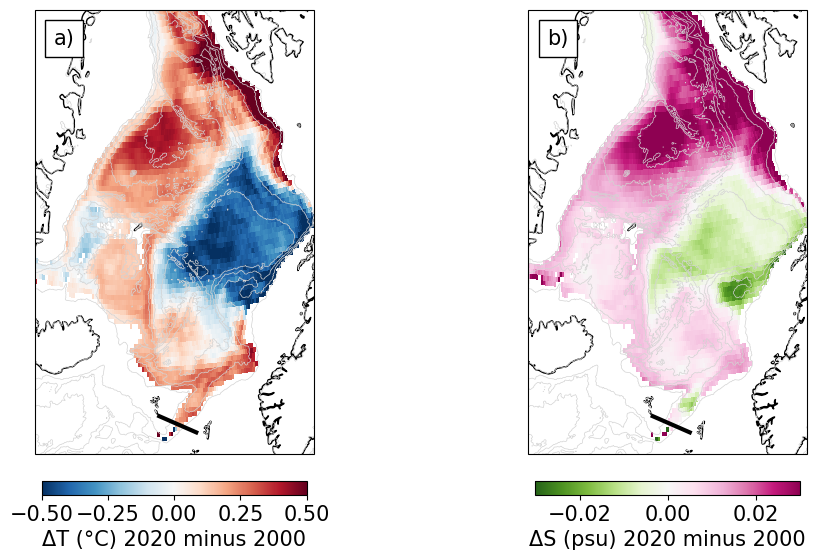

In [23]:
## then take mean temperature map of 2020 minus 2000 and see

temp_diff = mean_temp_maps.sel(year=2020) - mean_temp_maps.sel(year=2000)
salt_diff = mean_salt_maps.sel(year=2020) - mean_salt_maps.sel(year=2000)

# Plot
proj = ccrs.LambertConformal(central_longitude=-10, central_latitude=70)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={"projection": proj})

for ax in [ax1, ax2]:
    ax.set_extent([-20, 10, 59, 80], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.contour(
        mesh_mask.nav_lon,
        mesh_mask.nav_lat,
        bathymetry,
        levels=contour_levels,
        colors="lightgray",
        linewidths=0.5,
        transform=ccrs.PlateCarree(),
    )
    ax.plot(
        [-6.5, -2.5], [61.3, 60.3], color="k", transform=ccrs.PlateCarree(), linewidth=3
    )

m1 = ax1.pcolormesh(
    temp_diff.lon_bin,
    temp_diff.lat_bin,
    temp_diff.T * msk,
    cmap="RdBu_r",
    vmin=-0.5,
    vmax=0.5,
    transform=ccrs.PlateCarree(),
)
fig.colorbar(m1, ax=ax1, orientation="horizontal", pad=0.05, shrink=0.4).set_label(
    "ΔT (°C) 2020 minus 2000"
)

m2 = ax2.pcolormesh(
    salt_diff.lon_bin,
    salt_diff.lat_bin,
    salt_diff.T * msk,
    cmap="PiYG_r",
    vmin=-0.03,
    vmax=0.03,
    transform=ccrs.PlateCarree(),
)
fig.colorbar(m2, ax=ax2, orientation="horizontal", pad=0.05, shrink=0.4).set_label(
    "ΔS (psu) 2020 minus 2000"
)

for ax, label in zip([ax1, ax2], ["a)", "b)"]):
    ax.add_artist(
        AnchoredText(label, prop=dict(size=15), frameon=True, loc="upper left")
    )

plt.tight_layout()
plt.show()

In [ ]:
start_year = 2000
end_year = 2020

annual_data = {}

for year in range(start_year, end_year + 1):
    start_date = pd.Timestamp(f"{year}-01-01")
    end_date = pd.Timestamp(f"{year}-12-31")
    date_range = pd.date_range(start=start_date, end=end_date, freq="5D")
    start_index = (start_date - pd.Timestamp("2000-01-01")).days // 5  # '2003-01-01'
    end_index = (
        end_date - pd.Timestamp("2-01-01")
    ).days // 5 + 1  # +1 to include the end date
    selected_values = grouped_values[start_index:end_index]
    concatenated_data = xr.concat(selected_values, dim="trajectory")
    annual_data[year] = concatenated_data

In [ ]:
mean_temp_maps = {}

for year in tqdm.tqdm(range(2000, 2021)):
    temp_data = annual_data.get(year).temp
    lat, lon = rechunk_lat_lon(annual_data.get(year))
    mean_temp_maps[year] = get_mean_maps(temp_data, lat, lon).compute()

In [ ]:
mean_salt_maps = {}

for year in tqdm.tqdm(range(2000, 2021)):
    salt_data = annual_data.get(year).salt
    lat, lon = rechunk_lat_lon(annual_data.get(year))
    mean_salt_maps[year] = get_mean_maps(salt_data, lat, lon).compute()

In [ ]:
def concatenate_annual_data(mean_maps):
    years_to_concatenate = range(2000, 2021)
    data_arrays = []

    for year in years_to_concatenate:
        data_arrays.append(mean_maps.get(year))
    return data_arrays


overflow_temp_annual_means = (
    xr.concat(concatenate_annual_data(mean_temp_maps), dim="year")
    .assign_coords(year=("year", range(1995, 2021)))
    .transpose("year", "lat_bin", "lon_bin")
)
overflow_salt_annual_means = (
    xr.concat(concatenate_annual_data(mean_salt_maps), dim="year")
    .assign_coords(year=("year", range(1995, 2021)))
    .transpose("year", "lat_bin", "lon_bin")
)

In [26]:
def trends(x, y):
    y = y.values
    x = x.values
    SSH_dec_6_reshape = y.reshape(len(x), -1)

    num_lats, num_lons = y.shape[1:]

    trends = np.empty((num_lats, num_lons))
    p_values = np.empty((num_lats, num_lons))

    for i in range(num_lats):
        # print(i)
        for j in range(num_lons):
            # in linregress it's slope, inercept, r value, p value
            slope, _, _, p_value, _ = linregress(
                x, SSH_dec_6_reshape[:, i * num_lons + j]
            )
            trends[i, j] = slope
            p_values[i, j] = p_value
    trends_da = xr.DataArray(trends).rename({"dim_0": "lat_bin", "dim_1": "lon_bin"})
    p_values_da = xr.DataArray(p_values).rename(
        {"dim_0": "lat_bin", "dim_1": "lon_bin"}
    )
    return trends_da, p_values_da


def sig_test_95th(lagged_pval):
    sig_95th = np.less_equal(lagged_pval, 0.05)
    mask = np.ma.masked_invalid(lagged_pval[:, :])
    masked = np.ma.masked_where(np.ma.getmask(mask), sig_95th)
    return masked

In [27]:
overflow_temp_annual_means = xr.open_dataset(
    "netcdfs/mean_temp_2000_2020.nc"
).histogram_lon_lat
overflow_salt_annual_means = xr.open_dataset(
    "netcdfs/mean_salt_2000_2020.nc"
).histogram_lon_lat
overflow_depth_annual_means = xr.open_mfdataset(
    "netcdfs/mean_depth_2000_2020.nc"
).histogram_lon_lat

In [28]:
t = 2000
trend_2003_2020_T = trends(
    overflow_temp_annual_means.year.sel(year=slice(t, None)),
    overflow_temp_annual_means.sel(year=slice(t, None)),
)

trend_2003_2020_S = trends(
    overflow_salt_annual_means.year.sel(year=slice(t, None)),
    overflow_salt_annual_means.sel(year=slice(t, None)),
)

In [29]:
trends_2003_depth = trends(
    overflow_depth_annual_means.year.sel(year=slice(t, None)),
    overflow_depth_annual_means.sel(year=slice(t, None)),
)

In [30]:
lon, lat = trend_2003_2020_T[0].lon_bin, trend_2003_2020_T[0].lat_bin

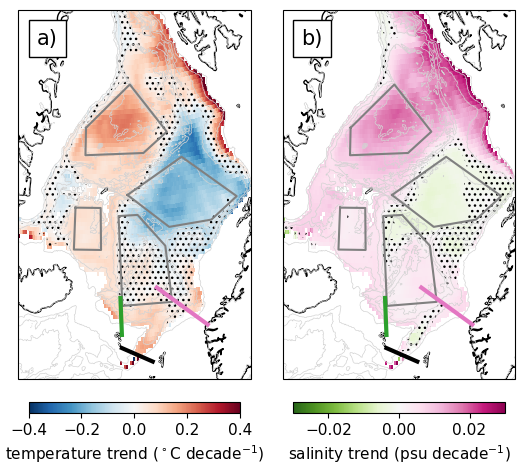

In [32]:
plt.rcParams.update({"font.size": 11})

proj = ccrs.LambertConformal(central_longitude=-10, central_latitude=70)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6), subplot_kw={"projection": proj})

# --- First map ---
# ax1.set_extent([-25, 9, 58, 82], crs=ccrs.PlateCarree())

ax1.set_extent([-20, 10, 59, 80], crs=ccrs.PlateCarree())
m1 = ax1.pcolormesh(
    mean_depth.lon_bin,
    mean_depth.lat_bin,
    trend_2003_2020_T[0].T * 10 * msk,
    cmap="RdBu_r",
    vmin=-0.4,
    vmax=0.4,
    transform=ccrs.PlateCarree(),
)
ax1.coastlines()
ax1.contourf(
    mean_depth.lon_bin,
    mean_depth.lat_bin,
    sig_test_95th(trend_2003_2020_T[1].T) * msk,
    [-0.232, 0.232],
    colors="none",
    hatches=["..."],
    transform=ccrs.PlateCarree(),
)
ax1.contour(
    mesh_mask.nav_lon,
    mesh_mask.nav_lat,
    bathymetry,
    levels=contour_levels,
    colors="lightgray",
    linewidths=0.5,
    alpha=1,
    transform=ccrs.PlateCarree(),
)
fig.colorbar(m1, ax=ax1, orientation="horizontal", pad=0.05, shrink=0.36).set_label(
    "temperature trend ($^\circ$C decade$^{-1}$)"
)
ax1.plot(x_GSea, y_GSea, color="gray", label="GSea", transform=ccrs.PlateCarree())
ax1.plot(
    x_Lofoten, y_Lofoten, color="gray", label="Lofoten", transform=ccrs.PlateCarree()
)
ax1.plot(
    x_Iceland, y_Iceland, color="gray", label="Iceland", transform=ccrs.PlateCarree()
)
ax1.plot(
    x_Norwegian,
    y_Norwegian,
    color="gray",
    label="Norwegian",
    transform=ccrs.PlateCarree(),
)
ax1.plot(
    [5.5, -1],
    [62.24, 65.0],
    color="tab:pink",
    label="Svinoy section",
    transform=ccrs.PlateCarree(),
    linewidth=3,
)
ax1.plot(
    [-6.43, -6.43],
    [62.15, 64.5],
    color="tab:green",
    label="N section",
    transform=ccrs.PlateCarree(),
    linewidth=3,
)
ax1.plot(
    [-6.5, -2.5], [61.3, 60.3], color="k", transform=ccrs.PlateCarree(), linewidth=3
)

# --- Second map ---
# ax2.set_extent([-25, 9, 58, 82], crs=ccrs.PlateCarree())
ax2.set_extent([-20, 10, 59, 80], crs=ccrs.PlateCarree())
m2 = ax2.pcolormesh(
    mean_depth.lon_bin,
    mean_depth.lat_bin,
    trend_2003_2020_S[0].T * 10 * msk,
    cmap="PiYG_r",
    vmin=-0.03,
    vmax=0.03,
    transform=ccrs.PlateCarree(),
)
ax2.coastlines()
ax2.contourf(
    mean_depth.lon_bin,
    mean_depth.lat_bin,
    sig_test_95th(trend_2003_2020_S[1].T) * msk,
    [-0.232, 0.232],
    colors="none",
    hatches=["..."],
    transform=ccrs.PlateCarree(),
)
ax2.contour(
    mesh_mask.nav_lon,
    mesh_mask.nav_lat,
    bathymetry,
    levels=contour_levels,
    colors="lightgray",
    linewidths=0.5,
    alpha=1,
    transform=ccrs.PlateCarree(),
)
fig.colorbar(m2, ax=ax2, orientation="horizontal", pad=0.05, shrink=0.36).set_label(
    "salinity trend (psu decade$^{-1}$)"
)
ax2.plot(x_GSea, y_GSea, color="gray", label="GSea", transform=ccrs.PlateCarree())
ax2.plot(
    x_Lofoten, y_Lofoten, color="gray", label="Lofoten", transform=ccrs.PlateCarree()
)
ax2.plot(
    x_Iceland, y_Iceland, color="gray", label="Iceland", transform=ccrs.PlateCarree()
)
ax2.plot(
    x_Norwegian,
    y_Norwegian,
    color="gray",
    label="Norwegian",
    transform=ccrs.PlateCarree(),
)
ax2.plot(
    [5.5, -1],
    [62.24, 65.0],
    color="tab:pink",
    label="Svinoy section",
    transform=ccrs.PlateCarree(),
    linewidth=3,
)
ax2.plot(
    [-6.43, -6.43],
    [62.15, 64.5],
    color="tab:green",
    label="N section",
    transform=ccrs.PlateCarree(),
    linewidth=3,
)
# ax2.plot([-15, -11.95], [66.25, 68.7], color='blue', label='LN section', transform=ccrs.PlateCarree())
ax2.plot(
    [-6.5, -2.5], [61.3, 60.3], color="k", transform=ccrs.PlateCarree(), linewidth=3
)

at = AnchoredText("a)", prop=dict(size=15), frameon=True, loc="upper left")
ax1.add_artist(at)

at = AnchoredText("b)", prop=dict(size=15), frameon=True, loc="upper left")
ax2.add_artist(at)

# Reduce horizontal space between maps
fig.subplots_adjust(wspace=-0.55)
# plt.savefig("Fig5_S_T_trends.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 6

In [ ]:
ds_Greenland_overflows = process_ocean_basins(ds_overflows)["greenland"]
Greenland_basin_cross = filter_trajectories(ds_Greenland_overflows, ds_overflows)
Greenland_masked = process_ocean_basins(Greenland_basin_cross["traj_line"])["greenland"]
Greenland_masked = Greenland_masked.assign_coords(
    start_time=Greenland_masked.start_time.compute()
)

In [ ]:
print("Greenland: computing salt time series...")
Greenland_salt_ts = (
    Greenland_masked.salt.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Greenland: computing temp time series...")
Greenland_temp_ts = (
    Greenland_masked.temp.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Greenland: computing depth time series...")
Greenland_depth_ts = (
    Greenland_masked.z.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Greenland: computing sigma0 time series...")
Greenland_sigma0_ts = (
    Greenland_masked.sigma0.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Greenland: all time series computed!")

In [ ]:
n_traj = Greenland_basin_cross["traj_line"].trajectory.size
print("Greenland: building dataset...")
ds_out = xr.Dataset(
    {
        "Greenland_temp": Greenland_temp_ts,
        "Greenland_salt": Greenland_salt_ts,
        "Greenland_depth": Greenland_depth_ts,
        "Greenland_sigma0": Greenland_sigma0_ts,
        "n_trajectories": xr.DataArray(n_traj),
    }
)
ds_out.attrs["n_trajectories"] = n_traj
ds_out.attrs["description"] = (
    "Mean temp, salinity, depth and sigma0 of Greenland basin crossing trajectories"
)
print("Greenland: saving to netcdf...")
ds_out.to_netcdf("Greenland_basin_cross_ts.nc")
print(f"Greenland: done! Saved Greenland_basin_cross_ts.nc with {n_traj} trajectories")

In [ ]:
# Lofoten
print("Lofoten: masking ds_overflows to basin...")
ds_Lofoten_overflows = process_ocean_basins(ds_overflows)["lofoten"]
print("Lofoten: filtering crossing trajectories...")
Lofoten_basin_cross = filter_trajectories(ds_Lofoten_overflows, ds_overflows)
print(
    f"Lofoten: {Lofoten_basin_cross['traj_line'].trajectory.size} crossing trajectories found"
)
print("Lofoten: re-masking crossing trajectories to basin...")
Lofoten_masked = process_ocean_basins(Lofoten_basin_cross["traj_line"])["lofoten"]
print("Lofoten: computing start_time coordinate...")
Lofoten_masked = Lofoten_masked.assign_coords(
    start_time=Lofoten_masked.start_time.compute()
)
print("Lofoten: computing salt time series...")
Lofoten_salt_ts = (
    Lofoten_masked.salt.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Lofoten: computing temp time series...")
Lofoten_temp_ts = (
    Lofoten_masked.temp.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Lofoten: computing depth time series...")
Lofoten_depth_ts = (
    Lofoten_masked.z.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Lofoten: computing sigma0 time series...")
Lofoten_sigma0_ts = (
    Lofoten_masked.sigma0.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Lofoten: all time series computed, building dataset...")
n_traj = Lofoten_basin_cross["traj_line"].trajectory.size
print(n_traj / ds_overflows.trajectory.size)
ds_out = xr.Dataset(
    {
        "Lofoten_temp": Lofoten_temp_ts,
        "Lofoten_salt": Lofoten_salt_ts,
        "Lofoten_depth": Lofoten_depth_ts,
        "Lofoten_sigma0": Lofoten_sigma0_ts,
        "n_trajectories": xr.DataArray(n_traj),
    }
)
ds_out.attrs["n_trajectories"] = n_traj
ds_out.attrs["description"] = (
    "Mean temp, salinity, depth and sigma0 of Lofoten basin crossing trajectories"
)
print("Lofoten: saving to netcdf...")
ds_out.to_netcdf("Lofoten_basin_cross_ts.nc")
print(f"Lofoten: done! Saved Lofoten_basin_cross_ts.nc with {n_traj} trajectories")

In [ ]:
# Iceland
print("Iceland: masking ds_overflows to basin...")
ds_Iceland_overflows = process_ocean_basins(ds_overflows)["iceland"]
print("Iceland: filtering crossing trajectories...")
Iceland_basin_cross = filter_trajectories(ds_Iceland_overflows, ds_overflows)
print(
    f"Iceland: {Iceland_basin_cross['traj_line'].trajectory.size} crossing trajectories found"
)
print("Iceland: re-masking crossing trajectories to basin...")
Iceland_masked = process_ocean_basins(Iceland_basin_cross["traj_line"])["iceland"]
print("Iceland: computing start_time coordinate...")
Iceland_masked = Iceland_masked.assign_coords(
    start_time=Iceland_masked.start_time.compute()
)
print("Iceland: computing salt time series...")
Iceland_salt_ts = (
    Iceland_masked.salt.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Iceland: computing temp time series...")
Iceland_temp_ts = (
    Iceland_masked.temp.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Iceland: computing depth time series...")
Iceland_depth_ts = (
    Iceland_masked.z.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Iceland: computing sigma0 time series...")
Iceland_sigma0_ts = (
    Iceland_masked.sigma0.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Iceland: all time series computed, building dataset...")
n_traj = Iceland_basin_cross["traj_line"].trajectory.size
print(n_traj / ds_overflows.trajectory.size)
ds_out = xr.Dataset(
    {
        "Iceland_temp": Iceland_temp_ts,
        "Iceland_salt": Iceland_salt_ts,
        "Iceland_depth": Iceland_depth_ts,
        "Iceland_sigma0": Iceland_sigma0_ts,
        "n_trajectories": xr.DataArray(n_traj),
    }
)
ds_out.attrs["n_trajectories"] = n_traj
ds_out.attrs["description"] = (
    "Mean temp, salinity, depth and sigma0 of Iceland basin crossing trajectories"
)
print("Iceland: saving to netcdf...")
ds_out.to_netcdf("Iceland_basin_cross_ts.nc")
print(f"Iceland: done! Saved Iceland_basin_cross_ts.nc with {n_traj} trajectories")

In [ ]:
# Norwegian
print("Norwegian: masking ds_overflows to basin...")
ds_Norwegian_overflows = process_ocean_basins(ds_overflows)["norwegian"]
print("Norwegian: filtering crossing trajectories...")
Norwegian_basin_cross = filter_trajectories(ds_Norwegian_overflows, ds_overflows)
print(
    f"Norwegian: {Norwegian_basin_cross['traj_line'].trajectory.size} crossing trajectories found"
)
print("Norwegian: re-masking crossing trajectories to basin...")
Norwegian_masked = process_ocean_basins(Norwegian_basin_cross["traj_line"])["norwegian"]
print("Norwegian: computing start_time coordinate...")
Norwegian_masked = Norwegian_masked.assign_coords(
    start_time=Norwegian_masked.start_time.compute()
)
print("Norwegian: computing salt time series...")
Norwegian_salt_ts = (
    Norwegian_masked.salt.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Norwegian: computing temp time series...")
Norwegian_temp_ts = (
    Norwegian_masked.temp.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Norwegian: computing depth time series...")
Norwegian_depth_ts = (
    Norwegian_masked.z.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Norwegian: computing sigma0 time series...")
Norwegian_sigma0_ts = (
    Norwegian_masked.sigma0.groupby("start_time")
    .mean(dim="trajectory")
    .mean(dim="obs")
    .compute()
)
print("Norwegian: all time series computed, building dataset...")
n_traj = Norwegian_basin_cross["traj_line"].trajectory.size
print(n_traj / ds_overflows.trajectory.size)
ds_out = xr.Dataset(
    {
        "Norwegian_temp": Norwegian_temp_ts,
        "Norwegian_salt": Norwegian_salt_ts,
        "Norwegian_depth": Norwegian_depth_ts,
        "Norwegian_sigma0": Norwegian_sigma0_ts,
        "n_trajectories": xr.DataArray(n_traj),
    }
)
ds_out.attrs["n_trajectories"] = n_traj
ds_out.attrs["description"] = (
    "Mean temp, salinity, depth and sigma0 of Norwegian basin crossing trajectories"
)
print("Norwegian: saving to netcdf...")
ds_out.to_netcdf("Norwegian_basin_cross_ts.nc")
print(f"Norwegian: done! Saved Norwegian_basin_cross_ts.nc with {n_traj} trajectories")

In [35]:
inpath = "netcdfs/"
Greenland_temp_ts = xr.open_dataset(
    f"{inpath}Greenland_basin_cross_ts.nc"
).Greenland_temp
Greenland_salt_ts = xr.open_dataset(
    f"{inpath}Greenland_basin_cross_ts.nc"
).Greenland_salt
Greenland_depth_ts = xr.open_dataset(
    f"{inpath}Greenland_basin_cross_ts.nc"
).Greenland_depth
Greenland_sigma0_ts = xr.open_dataset(
    f"{inpath}Greenland_basin_cross_ts.nc"
).Greenland_sigma0
Lofoten_temp_ts = xr.open_dataset(f"{inpath}Lofoten_basin_cross_ts.nc").Lofoten_temp
Lofoten_salt_ts = xr.open_dataset(f"{inpath}Lofoten_basin_cross_ts.nc").Lofoten_salt
Lofoten_depth_ts = xr.open_dataset(f"{inpath}Lofoten_basin_cross_ts.nc").Lofoten_depth
Lofoten_sigma0_ts = xr.open_dataset(f"{inpath}Lofoten_basin_cross_ts.nc").Lofoten_sigma0
Iceland_temp_ts = xr.open_dataset(f"{inpath}Iceland_basin_cross_ts.nc").Iceland_temp
Iceland_salt_ts = xr.open_dataset(f"{inpath}Iceland_basin_cross_ts.nc").Iceland_salt
Iceland_depth_ts = xr.open_dataset(f"{inpath}Iceland_basin_cross_ts.nc").Iceland_depth
Iceland_sigma0_ts = xr.open_dataset(f"{inpath}Iceland_basin_cross_ts.nc").Iceland_sigma0
Norwegian_temp_ts = xr.open_dataset(
    f"{inpath}Norwegian_basin_cross_ts.nc"
).Norwegian_temp
Norwegian_salt_ts = xr.open_dataset(
    f"{inpath}Norwegian_basin_cross_ts.nc"
).Norwegian_salt
Norwegian_depth_ts = xr.open_dataset(
    f"{inpath}Norwegian_basin_cross_ts.nc"
).Norwegian_depth
Norwegian_sigma0_ts = xr.open_dataset(
    f"{inpath}Norwegian_basin_cross_ts.nc"
).Norwegian_sigma0

In [36]:
def weighted_mean(data):
    gb_area = data.dx * data.dz
    numerator = (
        (data * gb_area).squeeze().sum(["z", "c"])
    )  # if want to depth average over range of depths, use native grid! .isel(z=slice...).then sum over z, y, and x
    denominator = (gb_area).sum(["c", "z"]).squeeze()
    div = numerator / denominator
    return div


def weighted_mean_sigma0(S_sigma0, data):
    gb_area = data.dx * data.dz
    numerator = (
        (S_sigma0 * gb_area).squeeze().sum(["z", "c"])
    )  # if want to depth average over range of depths, use native grid! .isel(z=slice...).then sum over z, y, and x
    denominator = (gb_area).sum(["c", "z"]).squeeze()
    div = numerator / denominator
    return div


S = xr.open_dataset("/gxfs_work/geomar/smomw452/GLORYS12/Data/S_section.nc")
S_sigma0 = (
    xr.apply_ufunc(
        sw.eos80.dens0,
        S.vosaline,
        S.votemper,
        dask="parallelized",
        output_dtypes=[np.float64],
    )
    - 1000
)
S_overflow = S.where(S_sigma0 > 28)

## N section

N = xr.open_dataset("/gxfs_work/geomar/smomw452/GLORYS12/Data/N_section.nc")
N_sigma0 = (
    xr.apply_ufunc(
        sw.eos80.dens0,
        N.vosaline,
        N.votemper,
        dask="parallelized",
        output_dtypes=[np.float64],
    )
    - 1000
)
N_overflow = N.where((N_sigma0 > 27.985))

In [37]:
plt.rcParams.update({"font.size": 14})

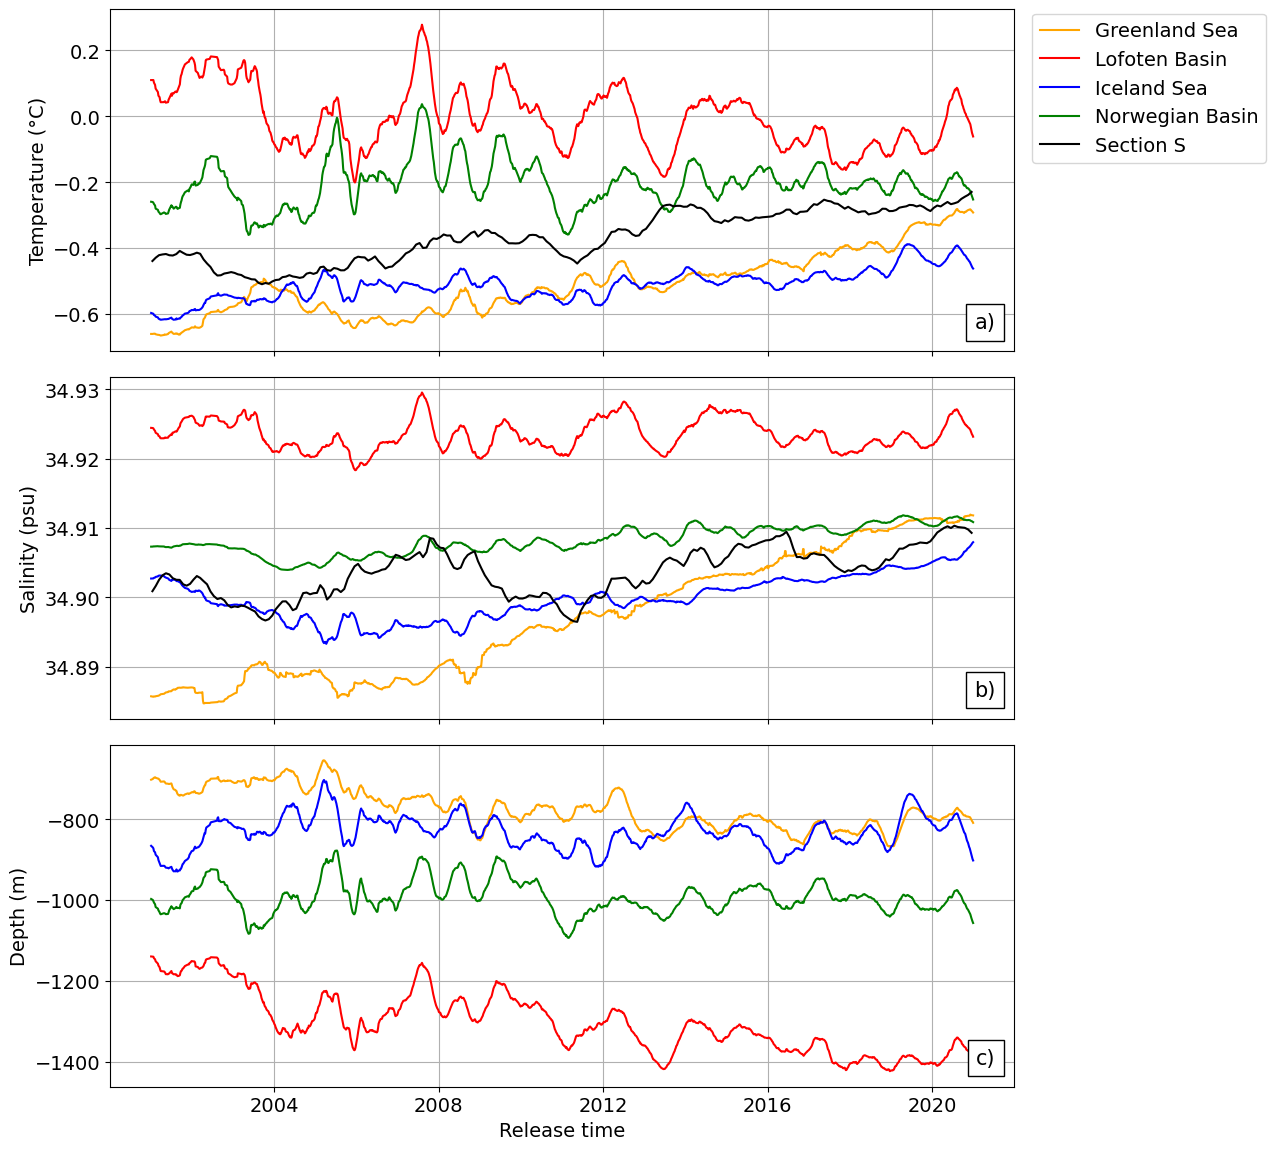

In [38]:
fig, axs = plt.subplots(3, 1, figsize=(13, 12), sharex=True)


Greenland_temp_ts.rolling(start_time=30).mean(dim="start_time").sel(
    start_time=slice("2001-01-01", None)
).plot(ax=axs[0], label="Greenland Sea", color="orange")
Lofoten_temp_ts.rolling(start_time=30).mean(dim="start_time").sel(
    start_time=slice("2001-01-01", None)
).plot(ax=axs[0], label="Lofoten Basin", color="red")
Iceland_temp_ts.rolling(start_time=30).mean(dim="start_time").sel(
    start_time=slice("2001-01-01", None)
).plot(ax=axs[0], label="Iceland Sea", color="blue")
Norwegian_temp_ts.rolling(start_time=30).mean(dim="start_time").sel(
    start_time=slice("2001-01-01", None)
).plot(ax=axs[0], label="Norwegian Basin", color="green")
weighted_mean(S_overflow).votemper.rolling(time_counter=30).mean(
    dim="time_counter"
).sel(time_counter=slice("2001-01-01", None)).plot(
    ax=axs[0], label="Section S", color="k"
)
axs[0].set_ylabel("Temperature (°C)")
at = AnchoredText("a)", prop=dict(size=15), frameon=True, loc="lower right")
axs[0].add_artist(at)
axs[0].legend(loc=(1.02, 0.55))
axs[0].set_xlabel("")
axs[0].grid()
# axs[0].set_ylim(None, .8)


Greenland_salt_ts.rolling(start_time=30).mean(dim="start_time").sel(
    start_time=slice("2001-01-01", None)
).plot(ax=axs[1], label="Greenland", color="orange")
Lofoten_salt_ts.rolling(start_time=30).mean(dim="start_time").sel(
    start_time=slice("2001-01-01", None)
).plot(ax=axs[1], label="Lofoten", color="red")
Iceland_salt_ts.rolling(start_time=30).mean(dim="start_time").sel(
    start_time=slice("2001-01-01", None)
).plot(ax=axs[1], label="Iceland", color="blue")
Norwegian_salt_ts.rolling(start_time=30).mean(dim="start_time").sel(
    start_time=slice("2001-01-01", None)
).plot(ax=axs[1], label="Norwegian", color="green")
weighted_mean(S_overflow).vosaline.rolling(time_counter=30).mean(
    dim="time_counter"
).sel(time_counter=slice("2001-01-01", None)).plot(
    ax=axs[1], label="Section S", color="k"
)
axs[1].set_ylabel("Salinity (psu)")
at = AnchoredText("b)", prop=dict(size=15), frameon=True, loc="lower right")
axs[1].add_artist(at)
axs[1].set_xlabel("")
axs[1].grid()

(
    -Greenland_depth_ts.rolling(start_time=30)
    .mean(dim="start_time")
    .sel(start_time=slice("2001-01-01", None))
).plot(ax=axs[2], label="Greenland", color="orange")
(
    -Lofoten_depth_ts.rolling(start_time=30)
    .mean(dim="start_time")
    .sel(start_time=slice("2001-01-01", None))
).plot(ax=axs[2], label="Lofoten", color="red")
(
    -Iceland_depth_ts.rolling(start_time=30)
    .mean(dim="start_time")
    .sel(start_time=slice("2001-01-01", None))
).plot(ax=axs[2], label="Iceland", color="blue")
(
    -Norwegian_depth_ts.rolling(start_time=30)
    .mean(dim="start_time")
    .sel(start_time=slice("2001-01-01", None))
).plot(ax=axs[2], label="Norwegian", color="green")
axs[2].set_xlabel("Release time")
axs[2].set_ylabel("Depth (m)")
at = AnchoredText("c)", prop=dict(size=15), frameon=True, loc="lower right")
axs[2].add_artist(at)
axs[2].grid()


plt.tight_layout()
# plt.savefig("Fig6_basins_time_series_vertical_v2.png", dpi=300, bbox_inches="tight")
plt.show()